## Статистическая мощность

### Ошибка False Negative

В статистике принято положительным результатом считать отвержение нулевой гипотезы, потому что обычно подтверждение альтернативы означает наличие бизнес-результата. Поэтому считается хорошим критерий, который чаще позволяет выявить бизнес-результат. И считают тогда не вероятность ошибки False Negative, а *мощность*, которая равна вероятности отвергнуть нулевую гипотезу при верности $\mathsf{H}_1$, то есть True Positive Rate.

## Мощность для задачи с доставкой

Применим новые знания о мощности для нашей задачи с доставкой. Из бизнес-соображений мы уже выбрали $\alpha = 0.05$, а значит знаем, что мы неправильно отвергаем гипотезу $\mathsf{H}_0:\ \mu = 0.5$ с вероятностью не более, чем $5\%$. То есть этим ограничена вероятность ошибки False Positive.

А с какой вероятностью мы будем *правильно* отвергать гипотезу? И какая у нас будет вероятность ошибки False Negative? На этот вопрос как раз ответит формула мощности.

Вспомним критерий, по которому мы принимаем решение:

$$ Q(\xi) = \sum\limits_{i=1}^n \xi_i - \text{количество успешных доставок} $$

$$ S = \{Q \geqslant 20\} $$

То есть если получаем хотя бы $20$ успешных доставок, то отвергаем $\mathsf{H}_0$.

Заметим, что, как и в прошлом пункте, мощность зависит от того, какое значение $\mu$ в нашей генеральной совокупности. Зафиксируем сначала параметр $\mu = 0.6$ и посчитаем мощность для него. Если истинный параметр такой, то статистика $Q$ имеет распределение $Binom(30, 0.6)$.

In [25]:
from scipy.stats import binom
import numpy
from matplotlib import pyplot

In [26]:
binom_h0 = binom(n=30, p=0.5)
binom_alternative = binom(n=30, p=0.6)
x_grid = numpy.arange(1, 31)
crit_reg = x_grid >= 20
probs_h0 = binom_h0.pmf(x_grid)
probs_alternative = binom_alternative.pmf(x_grid)

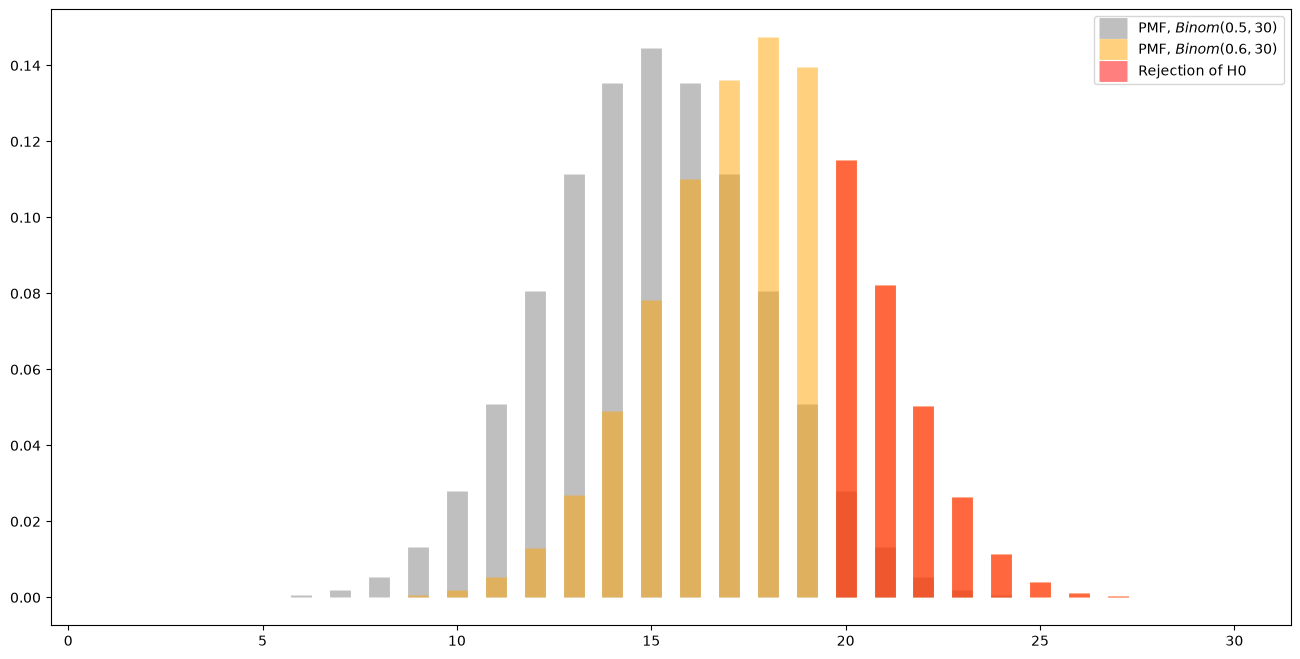

In [27]:
pyplot.figure(figsize=(16, 8))
pyplot.vlines(
    x_grid,
    0,
    probs_h0,
    linewidth=15.0,
    color="grey",
    label="PMF, $Binom(0.5, 30)$",
    alpha=0.5,
)
pyplot.vlines(
    x_grid,
    0,
    probs_alternative,
    linewidth=15.0,
    color="orange",
    label="PMF, $Binom(0.6, 30)$",
    alpha=0.5,
)
pyplot.vlines(
    x_grid[crit_reg],
    0,
    probs_alternative[crit_reg],
    linewidth=15.0,
    color="red",
    label="Rejection of H0",
    alpha=0.5,
)

pyplot.legend()
pyplot.show()

Число 20 искалось, просто повторение кода прошлого

In [28]:
def make_binom_criterion(n, mu=0.5, alpha=0.05):
    """Строит критерий для задачи с доставкой

    Параметры:
        n: количество доставок в эксперименте
        mu: вероятность успеха в нулевой гипотезе
        alpha: уровень значимости критерия

    Возвращает:
        C для критерия S = {Q >= C}
    """
    binom_for_delivery = binom(n, mu)
    return binom_for_delivery.ppf(1 - alpha) + 1

In [29]:
make_binom_criterion(n=30, mu=0.5, alpha=0.05)

np.float64(20.0)

Как и раньше, нас интересует вероятность получить $20$ или более успехов. Но если раньше мы смотрели на неё для распределения с $\mu=0.5$ и хотели, чтобы она была меньше $5\%$, то теперь мы смотрим при $\mu = 0.6$ и стремимся сделать эту величину как можно больше. По сравнению с вычислением FPR формула не поменяется, изменяется только $\mu$

In [30]:
critical_value = 20
fpr = 1 - binom(n=30, p=0.5).cdf(critical_value - 1)
power = 1 - binom(n=30, p=0.6).cdf(critical_value - 1)

print(f"False Positive Rate is {fpr:.1%}")
print(f"Power is {power:.1%}")

False Positive Rate is 4.9%
Power is 29.1%


Видно, что мощность около $30\%$. Это довольно маленькое значение, ведь если наш продукт прибылен, то мы увидим это с помощью нашего теста только с вероятностью в $30$ процентов. Мы легко можем пропустить эффект.

Что же можно сделать, чтобы сделать мощность выше? Чтобы разобраться, реализуем функцию мощности в общем виде.

In [31]:
def get_stat_power(N, mu_h0, mu_alternative, alpha):
    """Вычисляет статистическую мощность критерия для биномиального распределения

    Параметры:
        N - количество бернуллиевских экспериментов (размер выборки)
        mu_h0 - вероятность успеха в нулевой гипотезе
        mu_alternative - предполагаемая вероятность успеха в эксперименте
        alpha - уровень значимости критерия
    """
    binom_h0 = binom(N, mu_h0)
    binom_alternative = binom(N, mu_alternative)
    critical_value = binom_h0.ppf(1 - alpha) + 1
    return 1 - binom_alternative.cdf(critical_value - 1)

In [32]:
get_stat_power(30, 0.5, 0.6, alpha=0.05)

np.float64(0.2914718612234968)

In [33]:
get_stat_power(300, 0.5, 0.6, alpha=0.05)

np.float64(0.9655326717180744)

Принято считать, что приемлемой для работы мощностью считается $80\%$. Посмотрим, как изменяется мощность при росте размера выборки, и сколько нужно провести экспериментов, чтобы детектировать эффект при $\mu = 0.6$ в $80\%$ случаев.

In [34]:
n_grid = numpy.arange(10, 600, 10)
power = get_stat_power(n_grid, 0.5, 0.6, 0.05)

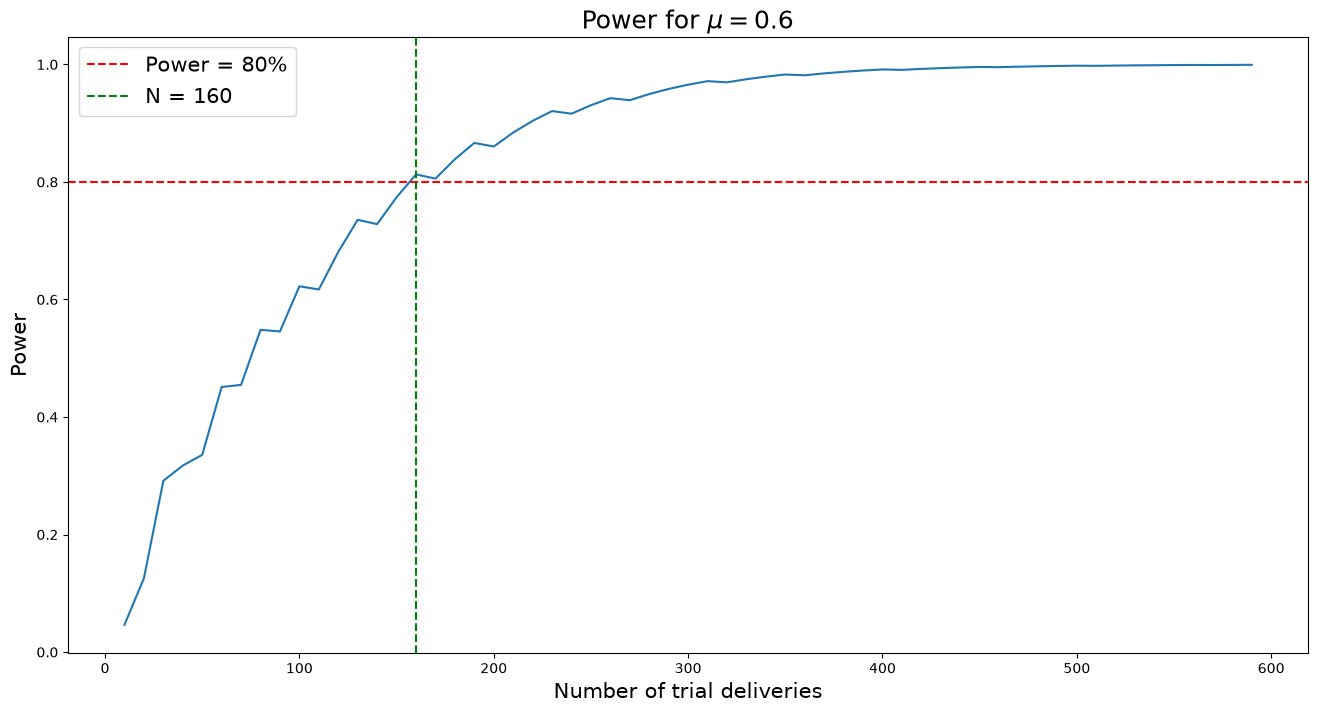

In [35]:
from cProfile import label


pyplot.figure(figsize=(16, 8))
pyplot.title(r'Power for $\mu = 0.6$', fontsize=18)
pyplot.xlabel('Number of trial deliveries', fontsize=15)
pyplot.ylabel('Power', fontsize=15)
pyplot.plot(n_grid, power)
pyplot.axhline(0.8, ls='--', color='red', label='Power = 80%')
min_n = n_grid[power >= 0.8].min()
pyplot.axvline(float(min_n), ls='--', color='green', label=f'N = {min_n}')
pyplot.legend(fontsize=15)
pyplot.show()

Видим, что для мощности в $80\%$ достаточно набрать 160 доставок.

А что, если мы хотим детектировать ещё меньший эффект? Например, если хотим отвергать гипотезу при $\mu = 0.51$. Часто улучшение вероятности успеха на $1\%$ может быть значимым для продукта, поэтому этот вопрос не лишен смысла.

In [36]:
n_grid = numpy.arange(10, 30000, 10)
power = get_stat_power(N=n_grid, mu_h0=0.5, mu_alternative=0.51, alpha=0.05)

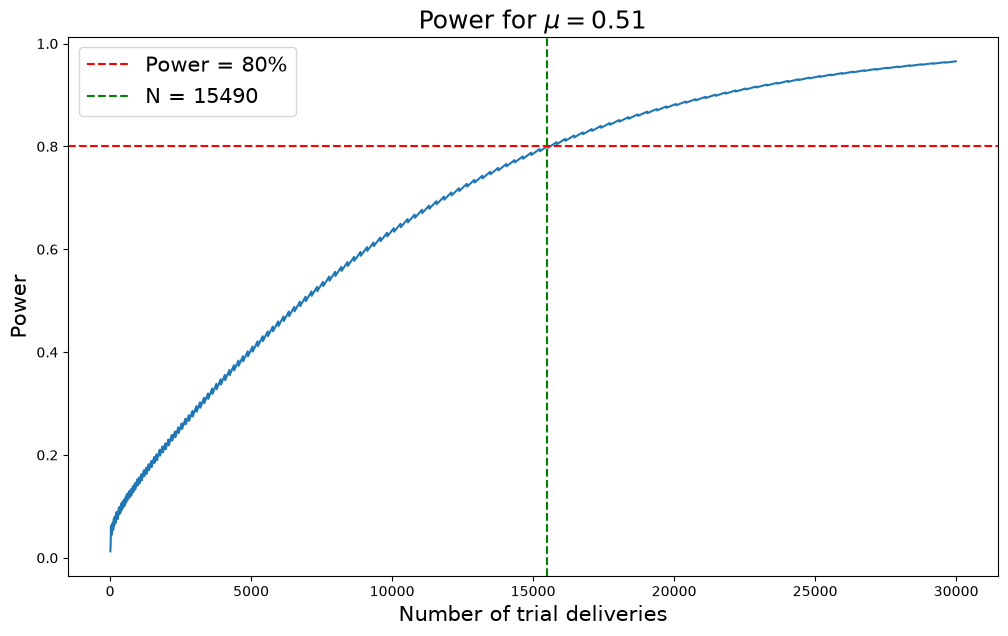

In [37]:
pyplot.figure(figsize=(12, 7))
pyplot.title(r'Power for $\mu = 0.51$', fontsize=18)
pyplot.xlabel('Number of trial deliveries', fontsize=15)
pyplot.ylabel('Power', fontsize=15)

pyplot.plot(n_grid, power)
pyplot.axhline(0.8, ls='--', color='red', label='Power = 80%')

# считаем минимальный размер выборки для мощности в 80%
min_n = n_grid[power >= 0.8][0]
pyplot.axvline(min_n, ls='--', color='green', label=f'N = {min_n}')

pyplot.legend(fontsize=15)
pyplot.show()

In [38]:
mu_grid = numpy.linspace(0.5, 1, 500)
power = get_stat_power(N=30, mu_h0=0.5, mu_alternative=mu_grid, alpha=0.05)

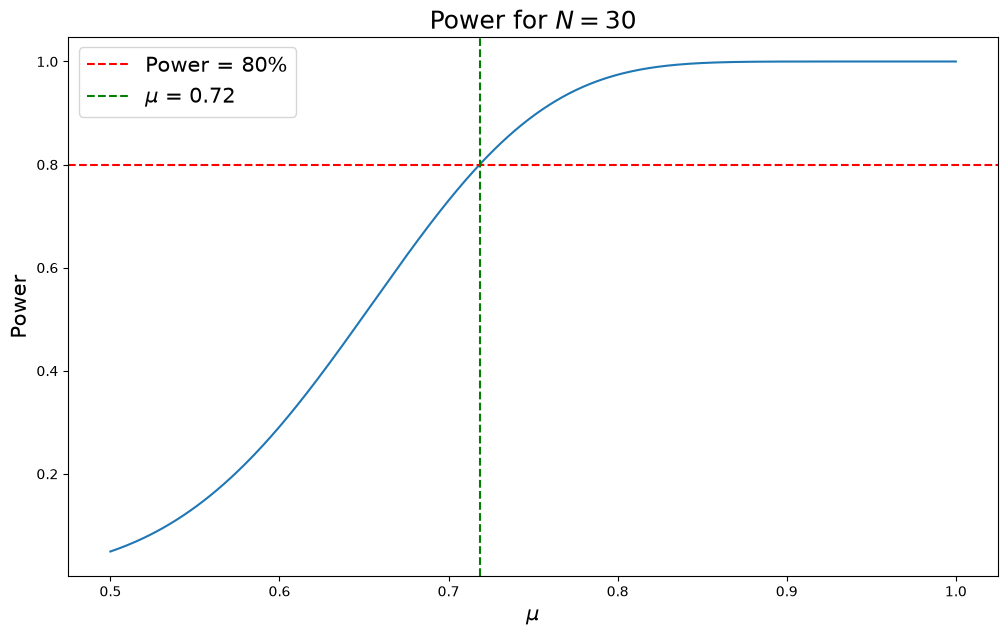

In [39]:
pyplot.figure(figsize=(12, 7))
pyplot.title('Power for $N = 30$', fontsize=18)
pyplot.xlabel(r'$\mu$', fontsize=15)
pyplot.ylabel('Power', fontsize=15)

pyplot.plot(mu_grid, power)
pyplot.axhline(y=0.8, color='red', linestyle='--', label='Power = 80%')
min_mu = mu_grid[power >= 0.8][0]
pyplot.axvline(min_mu, ls='--', color='green', label=rf'$\mu$ = {min_mu:.2f}')
pyplot.legend(fontsize=15)
pyplot.show()

В нашем эксперименте мы хорошо детектируем эффект, только если вероятность успеха в генеральной совокупности хотя бы $72\%$.